<a href="https://colab.research.google.com/github/amaansadat/SRDT/blob/main/K_NN_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#in knn, K=No. of neighbours
#small K=high variance(overfitting)
#large K=high bias(underfitting)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
iris=load_iris()

In [ ]:
X=iris.data

In [ ]:
y=iris.target

In [ ]:
df=pd.DataFrame(X, columns=iris.feature_names)
df['target']=y
df['target']=df['target'].map({0 : 'setosa', 1 : 'versicolor', 2 : 'virginica'})
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

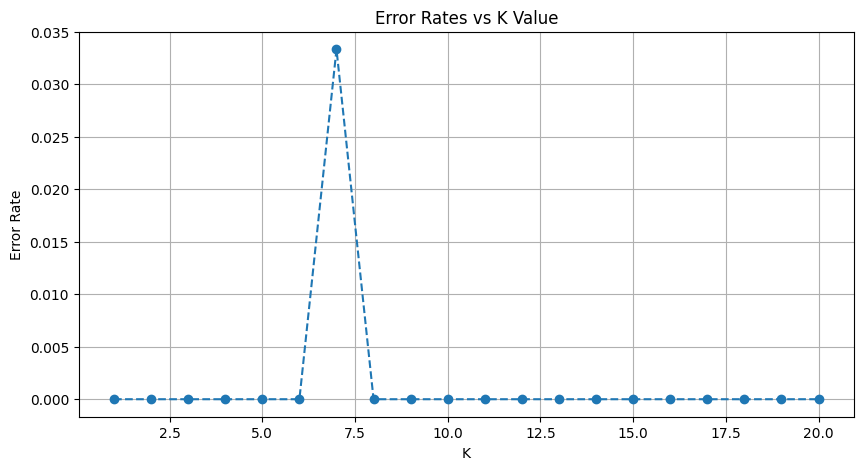

In [ ]:
error_rates = []

for k in range(1,21):
    knn=KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train ,y_train)
    pred_k=knn.predict(X_test)
    error_rates.append(np.mean(pred_k !=y_test))

#Plot error rates vs k
plt.figure(figsize=(10, 5))
plt.plot(range(1,21), error_rates, marker='o', linestyle='--')
plt.title('Error Rates vs K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.grid(True)
plt.show()

In [ ]:
from sklearn.model_selection import GridSearchCV
#Tune K using GridSearchCV
param_grid = {'n_neighbors' : np.arange(1,21)}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5)#cv=5 means cross validation has 5 folds
grid.fit(X_train, y_train)

print("Best K:", grid.best_params_['n_neighbors'])

Best K: 3


In [ ]:
#Train KNN with Best K
best_k=grid.best_params_['n_neighbors']
knn_best=KNeighborsClassifier(n_neighbors=best_k)
knn_best.fit(X_train,y_train)
y_pred=knn_best.predict(X_test)

In [ ]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("Accuracy Score:", accuracy_score(y_test, y_pred))

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        10
           1       1.00      1.00      1.00         9
           2       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

Confusion Matrix:

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
Accuracy Score: 1.0


In [ ]:
#Decision Metric Comparision
metrics=['euclidean','manhattan','chebyshev','cosine','minkowski']
for metric in metrics:
    knn = KNeighborsClassifier(n_neighbors=best_k, metric=metric)
    knn.fit(X_train, y_train)
    y_pred=knn.predict(X_test)
    print(f"\nMetric: {metric}")
    print("Accuracy: ",accuracy_score(y_test,y_pred))
    print(confusion_matrix(y_test,y_pred))
    print(confusion_matrix(y_test,y_pred))


Metric: euclidean
Accuracy:  1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Metric: manhattan
Accuracy:  1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Metric: chebyshev
Accuracy:  1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]

Metric: cosine
Accuracy:  0.9666666666666667
[[10  0  0]
 [ 0  9  0]
 [ 0  1 10]]
[[10  0  0]
 [ 0  9  0]
 [ 0  1 10]]

Metric: minkowski
Accuracy:  1.0
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]
